<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   company   2400 non-null   object 
 1   country   2400 non-null   object 
 2   img_url   2400 non-null   object 
 3   name      2400 non-null   object 
 4   price     2400 non-null   float64
 5   ratings   2400 non-null   int64  
 6   rum_url   2400 non-null   object 
 7   score     2400 non-null   float64
 8   type      2382 non-null   object 
 9   br_score  2400 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 187.6+ KB
None


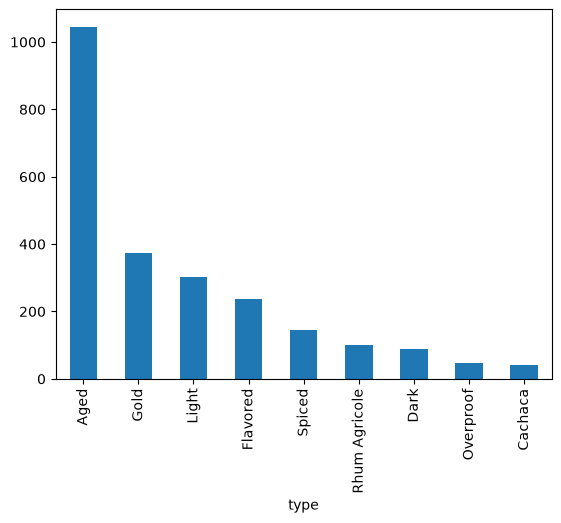

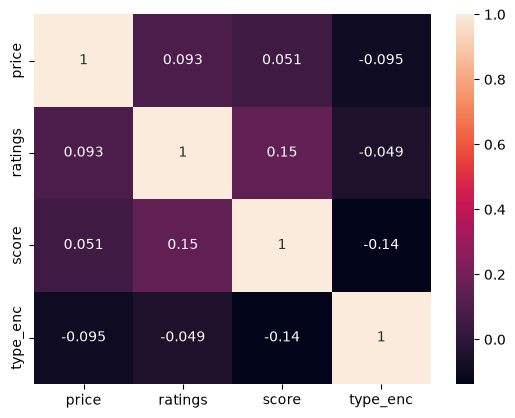

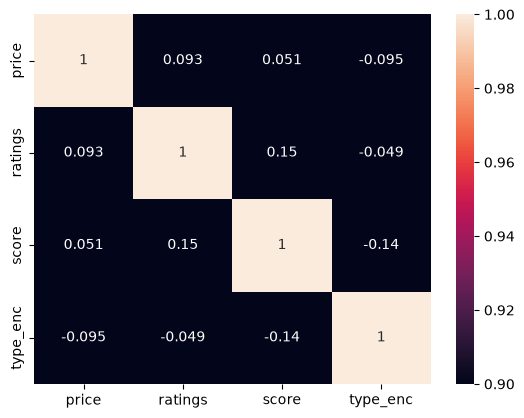

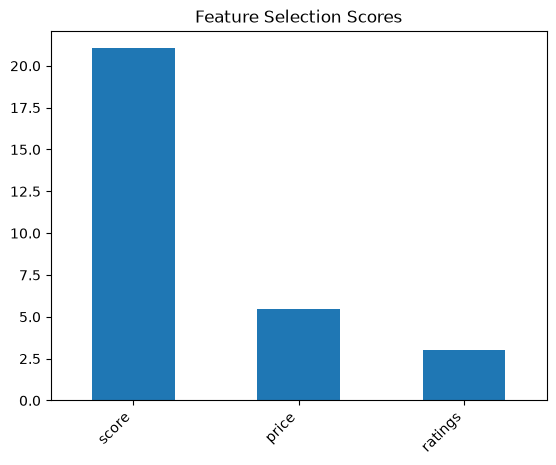

   1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  9.0
0  0.4  0.4  0.0  0.2  0.0  0.0  0.0  0.0  0.0
0.4429530201342282
              precision    recall  f1-score   support

         1.0       0.54      0.82      0.65       298
         2.0       0.23      0.10      0.14        94
         3.0       0.19      0.06      0.09        70
         4.0       0.20      0.17      0.18        47
         5.0       0.00      0.00      0.00        31
         6.0       0.00      0.00      0.00         9
         7.0       0.00      0.00      0.00        26
         8.0       0.00      0.00      0.00        17
         9.0       0.00      0.00      0.00         4

    accuracy                           0.44       596
   macro avg       0.13      0.13      0.12       596
weighted avg       0.34      0.44      0.37       596



c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\python\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\python\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\python\Lib\site-pac

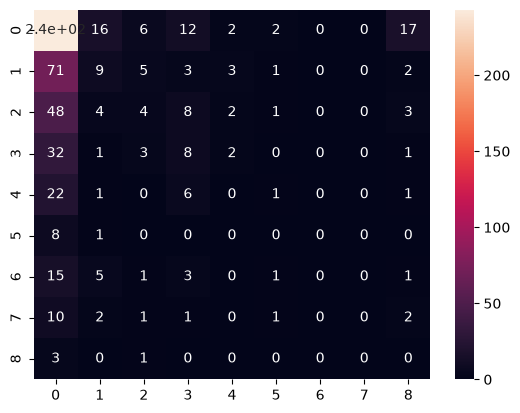

In [24]:
# GIVEN
# =====
# Input features are price, ratings, and score.
# Output feature is type.
# You will be creating a KNN model with default arguments (don't change k).
# When you call train_test_split be sure to set shuffle to false.
# *Hint - your model might not like nans, get rid of them!

# Import
# !pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv('../data/rum_data.csv', encoding='latin-1')
# df.head()
print(df.info())

# narrow data to input/output
df = df.drop(columns=["company", "country", "img_url", "name", "rum_url", "br_score"])
df = df.loc[df["type"].notna()] # drop nan

# Draw a graph for class balance
df['type'].value_counts().plot(kind="bar")
plt.show()

# encode type
df.loc[df['type'] == 'Aged', 'type_enc']          = 1 # Aged
df.loc[df['type'] == 'Gold', 'type_enc']          = 2 # Gold
df.loc[df['type'] == 'Light', 'type_enc']         = 3 # Light
df.loc[df['type'] == 'Flavored', 'type_enc']      = 4 # Flavored
df.loc[df['type'] == 'Spiced', 'type_enc']        = 5 # Spiced
df.loc[df['type'] == 'Rhum Agricole', 'type_enc'] = 6 # Rhum Agricole
df.loc[df['type'] == 'Dark', 'type_enc']          = 7 # Dark
df.loc[df['type'] == 'Overproof', 'type_enc']     = 8 # Overproof
df.loc[df['type'] == 'Cachaca', 'type_enc']       = 9 # Cachaca

# drop type, set input/output
df = df.drop(columns="type")
X = df[['price', 'ratings', 'score']]
y = df["type_enc"]

# Draw a correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Draw a collinearity plot
sns.heatmap(df.corr(numeric_only=True), vmin=0.9, vmax=1, annot=True)
plt.show()

# SelectK
from sklearn.feature_selection import SelectKBest, f_classif
kselect = SelectKBest(k="all", score_func=f_classif)
X_best = kselect.fit_transform(X, y)
# graph scores
scores = pd.Series(kselect.scores_, index=X.columns)
scores.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Selection Scores')
plt.xticks(rotation=45, ha='right')
plt.show()

# KNN
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)
model = KNeighborsClassifier()
model.fit(X_train, y_train)

# make pred, score it
point = [[30, 8, 5.5]]
pred = model.predict(point)
proba = model.predict_proba([[30, 8, 5.5]])
print(pd.DataFrame(proba, columns=model.classes_))

# Get estimator's score
print(model.score(X_test, y_test))

# Generate a classification report
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Draw a confusion matrix for the estimator
from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(y_test, y_pred)
sns.heatmap(cmat, annot=True)
plt.show()